# Benchmark: probabilistic ROI-trim vs. baseline

Loads the training-history pickles produced by `optimize/scripts/benchmark_roi_trim.sh` and compares runtime, peak GPU memory, and loss convergence between the trimmed (`roi_nticks=400`) and baseline (`roi_nticks=1999`) configurations.

In [18]:
import glob, os, pickle, re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

BASE_PATH = Path("/sdf/group/neutrino/cyifan/diff_sim_playground/larndsim_position_insensitive_loss")
BENCH_DIR = BASE_PATH / "fit_result" / "benchmark_roi_trim"
WARMUP_STEPS = 2   # skip first N steps for aggregate stats (JIT compile happens here)

# Explicit config selection — set to None to auto-discover every pickle in BENCH_DIR,
# or pass a list of {label, glob} dicts to compare specific runs side-by-side.
# The example below reproduces the request: baseline (default H=10, V=100) vs.
# trimmed with H=6 / V=32.
RUN_SPEC = [
    {"label": "baseline (H=10, V=100, roi=1999)",
     "glob":  "history_iter*_benchmark_*_baseline_roi1999_pad1999_it*.pkl"},
    {"label": "trimmed  (H=6,  V=32,  roi=400)",
     "glob":  "history_iter*_benchmark_*_trimmed_roi400_pad_Nhits6_Nbeam32_it*.pkl"},
]

def load_history(path):
    with open(path, "rb") as f:
        return pickle.load(f)

# Legacy auto-label parser — kept for RUN_SPEC=None mode. Handles both filename styles:
#   *_<mode>_roi<X>_pad<Y>_it<Z>            (old, H=default, V=default)
#   *_<mode>_roi<X>_pad_Nhits<H>_Nbeam<V>_it<Z>  (new, explicit H and V)
_LEGACY_RE = re.compile(
    r"_(?P<mode>trimmed|baseline)_roi(?P<roi>\d+)"
    r"(?:_pad(?P<pad>\d+)"
    r"|_pad_Nhits(?P<nhits>\d+)_Nbeam(?P<nbeam>\d+))"
)

def auto_label_from_path(path):
    m = _LEGACY_RE.search(Path(path).stem)
    if not m:
        return Path(path).stem
    parts = [f"{m.group('mode')}", f"roi={m.group('roi')}"]
    if m.group("pad"):
        parts.append(f"pad={m.group('pad')}")
    if m.group("nhits"):
        parts.append(f"H={m.group('nhits')}")
    if m.group("nbeam"):
        parts.append(f"V={m.group('nbeam')}")
    return f"{parts[0]} ({', '.join(parts[1:])})"

def resolve_runs(spec, bench_dir):
    """Return an ordered dict {display_label: history_dict}."""
    runs = {}
    if spec is None:
        for p in sorted(glob.glob(str(bench_dir / "history_iter*.pkl"))):
            runs[auto_label_from_path(p)] = load_history(p)
        return runs
    for entry in spec:
        matches = sorted(glob.glob(str(bench_dir / entry["glob"])))
        if not matches:
            print(f"  WARNING: no match for {entry['label']}  <-  {entry['glob']}")
            continue
        if len(matches) > 1:
            print(f"  NOTE: {entry['label']} matched {len(matches)} files; using newest.")
            matches.sort(key=lambda p: os.path.getmtime(p))
        runs[entry["label"]] = load_history(matches[-1])
        print(f"  {entry['label']:<40s} <- {Path(matches[-1]).name}")
    return runs

print("Resolving runs from", BENCH_DIR)
runs = resolve_runs(RUN_SPEC, BENCH_DIR)
print(f"\n{len(runs)} run(s) loaded: {list(runs.keys())}")

Resolving runs from /sdf/group/neutrino/cyifan/diff_sim_playground/larndsim_position_insensitive_loss/fit_result/benchmark_roi_trim
  baseline (H=10, V=100, roi=1999)         <- history_iter100_benchmark_A2-B2-C2-D2_baseline_roi1999_pad1999_it100.pkl
  trimmed  (H=6,  V=32,  roi=400)          <- history_iter100_benchmark_A2-B2-C2-D2_trimmed_roi400_pad_Nhits6_Nbeam32_it100.pkl

2 run(s) loaded: ['baseline (H=10, V=100, roi=1999)', 'trimmed  (H=6,  V=32,  roi=400)']


In [19]:
# `runs` was populated in the setup cell above. Peek at its keys / step counts.
for label, h in runs.items():
    n = len(h.get("step_time", []))
    mem_n = len(h.get("memory", []))
    print(f"  {label:<45s}  step_time n={n}  memory n={mem_n}")

  baseline (H=10, V=100, roi=1999)               step_time n=100  memory n=100
  trimmed  (H=6,  V=32,  roi=400)                step_time n=100  memory n=100


## Summary table

In [20]:
def summarize(history, warmup=WARMUP_STEPS):
    step_times = np.array(history.get("step_time", []), dtype=float)
    mem = history.get("memory", [])
    peak_bytes = np.array([m.get("peak_bytes_in_use", np.nan) for m in mem], dtype=float)
    inuse_bytes = np.array([m.get("bytes_in_use", np.nan) for m in mem], dtype=float)
    warm = step_times[warmup:] if len(step_times) > warmup else np.array([])
    return {
        "n_steps": len(step_times),
        "compile_time_s": float(step_times[0]) if len(step_times) else float("nan"),
        "median_step_ms": float(np.median(warm) * 1000) if warm.size else float("nan"),
        "p90_step_ms": float(np.percentile(warm, 90) * 1000) if warm.size else float("nan"),
        "min_step_ms": float(warm.min() * 1000) if warm.size else float("nan"),
        "peak_gpu_gb": float(np.nanmax(peak_bytes)) / 1e9 if peak_bytes.size else float("nan"),
        "final_in_use_gb": float(inuse_bytes[-1]) / 1e9 if inuse_bytes.size else float("nan"),
    }

print(f"{'run':<45s} {'steps':>6s} {'compile(s)':>11s} {'median(ms)':>11s} {'p90(ms)':>9s} {'min(ms)':>9s} {'peak(GB)':>10s}")
print("-" * 105)
for label, h in runs.items():
    s = summarize(h)
    print(f"{label:<45s} {s['n_steps']:>6d} {s['compile_time_s']:>11.2f} "
          f"{s['median_step_ms']:>11.1f} {s['p90_step_ms']:>9.1f} {s['min_step_ms']:>9.1f} "
          f"{s['peak_gpu_gb']:>10.3f}")

# Also compute deltas trimmed vs baseline if both present
trimmed_key = next((k for k in runs if "trimmed" in k), None)
baseline_key = next((k for k in runs if "baseline" in k), None)
if trimmed_key and baseline_key:
    t = summarize(runs[trimmed_key])
    b = summarize(runs[baseline_key])
    print()
    print("Trimmed vs. Baseline")
    print(f"  median step time: {t['median_step_ms']:.1f} ms  vs  {b['median_step_ms']:.1f} ms   "
          f"({(b['median_step_ms']/t['median_step_ms'] if t['median_step_ms']>0 else float('nan')):.2f}x speedup)")
    print(f"  peak GPU memory : {t['peak_gpu_gb']:.3f} GB  vs  {b['peak_gpu_gb']:.3f} GB   "
          f"({(b['peak_gpu_gb']-t['peak_gpu_gb']):+.3f} GB saved)")

run                                            steps  compile(s)  median(ms)   p90(ms)   min(ms)   peak(GB)
---------------------------------------------------------------------------------------------------------
baseline (H=10, V=100, roi=1999)                 100       54.39      4670.3    5090.4    1400.5     22.838
trimmed  (H=6,  V=32,  roi=400)                  100       49.27      3978.9    4668.5     869.2     16.380

Trimmed vs. Baseline
  median step time: 3978.9 ms  vs  4670.3 ms   (1.17x speedup)
  peak GPU memory : 16.380 GB  vs  22.838 GB   (+6.458 GB saved)


## Runtime per iteration

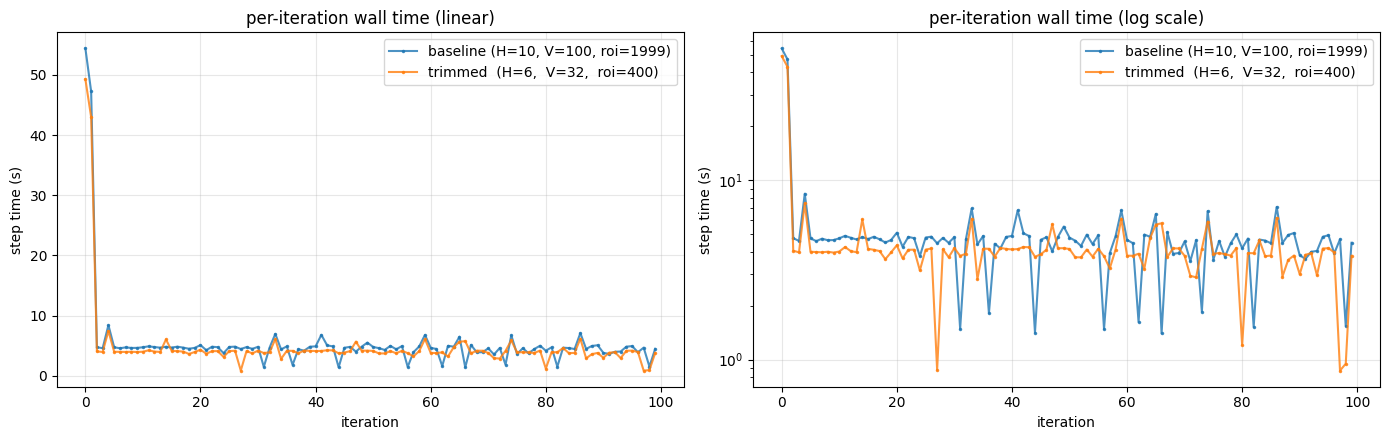

In [21]:
fig, (ax_lin, ax_log) = plt.subplots(1, 2, figsize=(14, 4.5))
for label, h in runs.items():
    st = np.array(h.get("step_time", []))
    x = np.arange(len(st))
    ax_lin.plot(x, st, marker=".", markersize=3, alpha=0.8, label=label)
    ax_log.semilogy(x, st, marker=".", markersize=3, alpha=0.8, label=label)
for ax, title in ((ax_lin, "linear"), (ax_log, "log scale")):
    ax.set_xlabel("iteration")
    ax.set_ylabel("step time (s)")
    ax.set_title(f"per-iteration wall time ({title})")
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

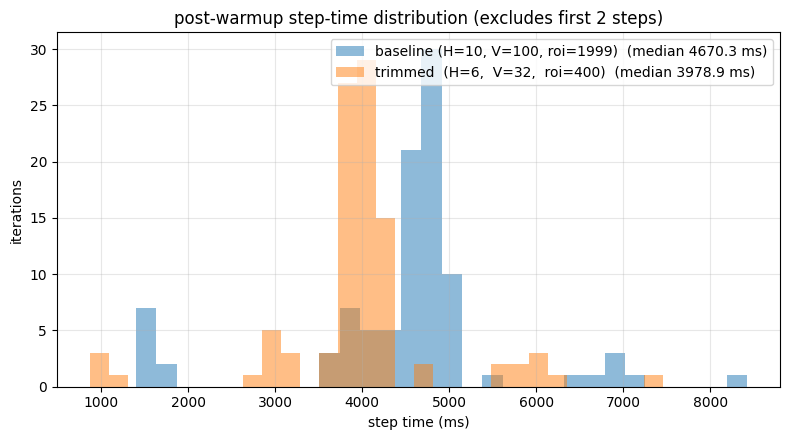

In [22]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for label, h in runs.items():
    st = np.array(h.get("step_time", []))[WARMUP_STEPS:]
    if st.size == 0:
        continue
    ax.hist(st * 1000, bins=30, alpha=0.5, label=f"{label}  (median {np.median(st)*1000:.1f} ms)")
ax.set_xlabel("step time (ms)")
ax.set_ylabel("iterations")
ax.set_title(f"post-warmup step-time distribution (excludes first {WARMUP_STEPS} steps)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Peak GPU memory over the run

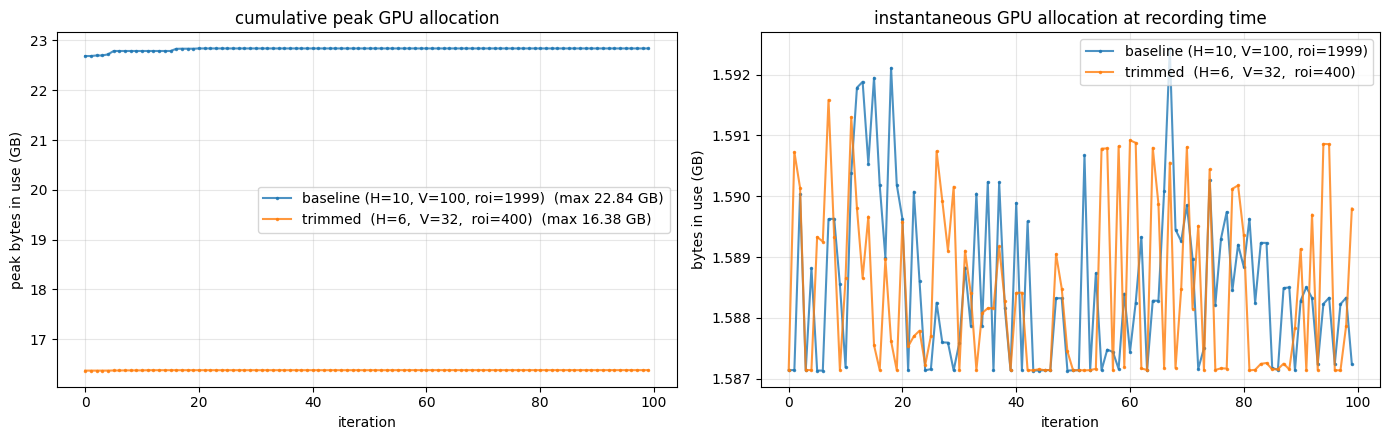

In [23]:
fig, (ax_peak, ax_inuse) = plt.subplots(1, 2, figsize=(14, 4.5))
for label, h in runs.items():
    mem = h.get("memory", [])
    peak = np.array([m.get("peak_bytes_in_use", np.nan) for m in mem]) / 1e9
    inuse = np.array([m.get("bytes_in_use", np.nan) for m in mem]) / 1e9
    x = np.arange(len(mem))
    ax_peak.plot(x, peak, marker=".", markersize=3, alpha=0.8, label=f"{label}  (max {np.nanmax(peak):.2f} GB)")
    ax_inuse.plot(x, inuse, marker=".", markersize=3, alpha=0.8, label=label)
ax_peak.set_xlabel("iteration")
ax_peak.set_ylabel("peak bytes in use (GB)")
ax_peak.set_title("cumulative peak GPU allocation")
ax_peak.grid(True, alpha=0.3)
ax_peak.legend()
ax_inuse.set_xlabel("iteration")
ax_inuse.set_ylabel("bytes in use (GB)")
ax_inuse.set_title("instantaneous GPU allocation at recording time")
ax_inuse.grid(True, alpha=0.3)
ax_inuse.legend()
plt.tight_layout()
plt.show()

## Loss convergence — correctness sanity check

If the trim is behaving well, the two loss curves should track each other closely. Divergence indicates the trimmed window is dropping mass the loss cares about.

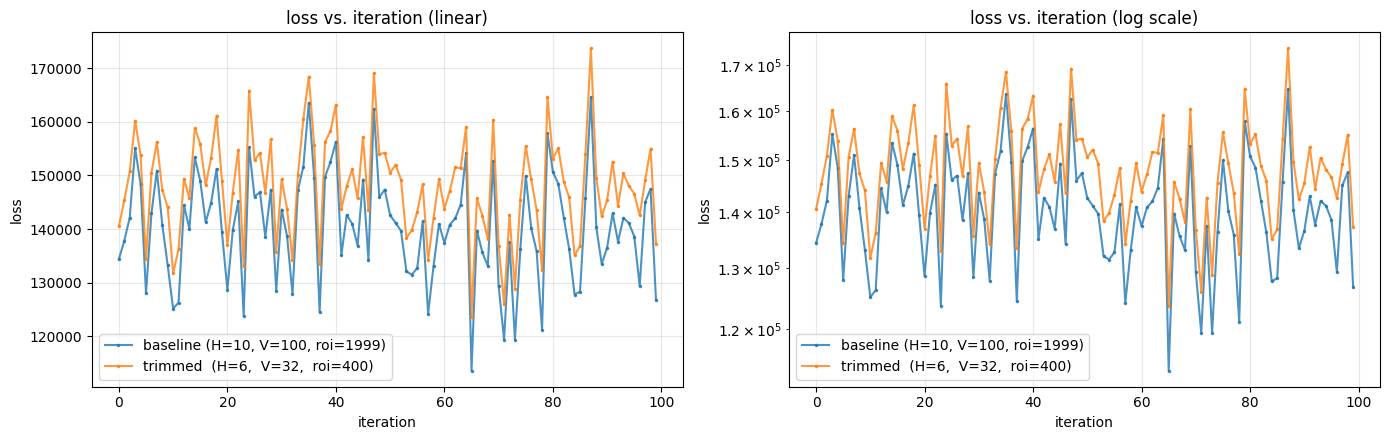

In [24]:
fig, (ax_lin, ax_log) = plt.subplots(1, 2, figsize=(14, 4.5))
for label, h in runs.items():
    loss = np.array(h.get("losses_iter", []))
    x = np.arange(len(loss))
    ax_lin.plot(x, loss, marker=".", markersize=3, alpha=0.8, label=label)
    # log-plot needs positive values
    pos = loss > 0
    if pos.any():
        ax_log.semilogy(x[pos], loss[pos], marker=".", markersize=3, alpha=0.8, label=label)
for ax, title in ((ax_lin, "linear"), (ax_log, "log scale")):
    ax.set_xlabel("iteration")
    ax.set_ylabel("loss")
    ax.set_title(f"loss vs. iteration ({title})")
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

## Parameter trajectories

Second correctness check: for the same seed, both configs should walk through parameter space similarly.

Params fit: ['Ab', 'eField', 'kb', 'lifetime', 'long_diff', 'total', 'tran_diff']


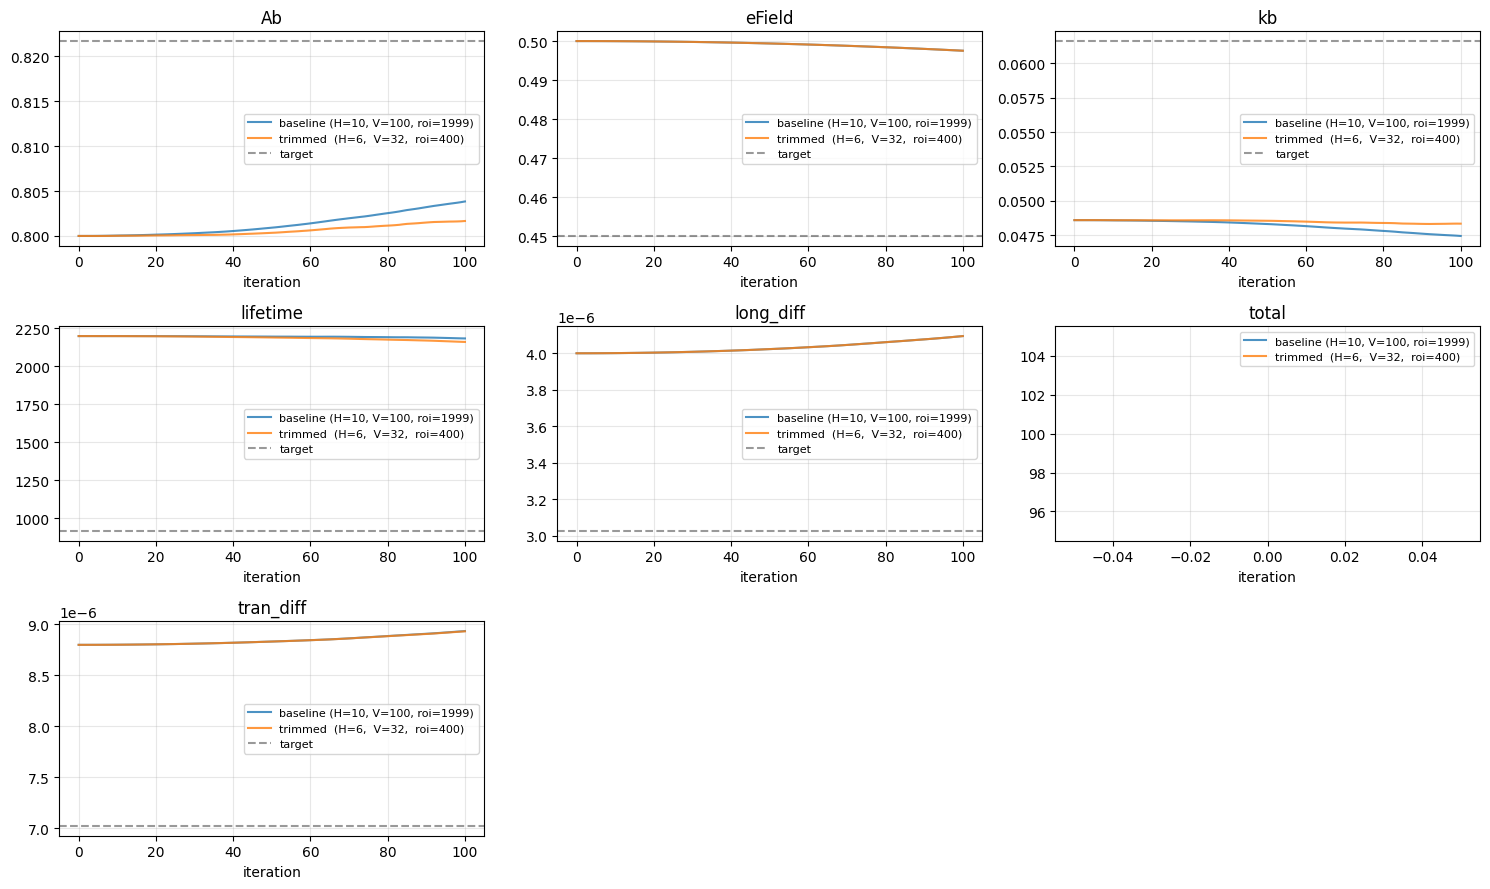

In [25]:
# Discover which physics params were fit (any key ending with '_iter' but not 'losses_iter' or 'aux_iter').
def fit_param_names(history):
    skip = {"losses_iter", "aux_iter"}
    return sorted(
        k[:-len("_iter")]
        for k in history.keys()
        if k.endswith("_iter") and k not in skip
    )

any_run = next(iter(runs.values()))
params = fit_param_names(any_run)
print("Params fit:", params)

n = len(params)
cols = 3
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 3 * rows), squeeze=False)
for ax, p in zip(axes.flat, params):
    for label, h in runs.items():
        vals = np.array(h.get(f"{p}_iter", []), dtype=float)
        ax.plot(vals, label=label, alpha=0.8)
    target = any_run.get(f"{p}_target", None)
    if target and len(target) > 0:
        try:
            tgt = float(target[0])
            ax.axhline(tgt, ls="--", color="k", alpha=0.4, label="target")
        except Exception:
            pass
    ax.set_title(p)
    ax.set_xlabel("iteration")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
# hide unused axes
for ax in axes.flat[n:]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

## Extra: gradient-norm history

Sanity check that the gradients are finite and comparable in magnitude between the two runs.

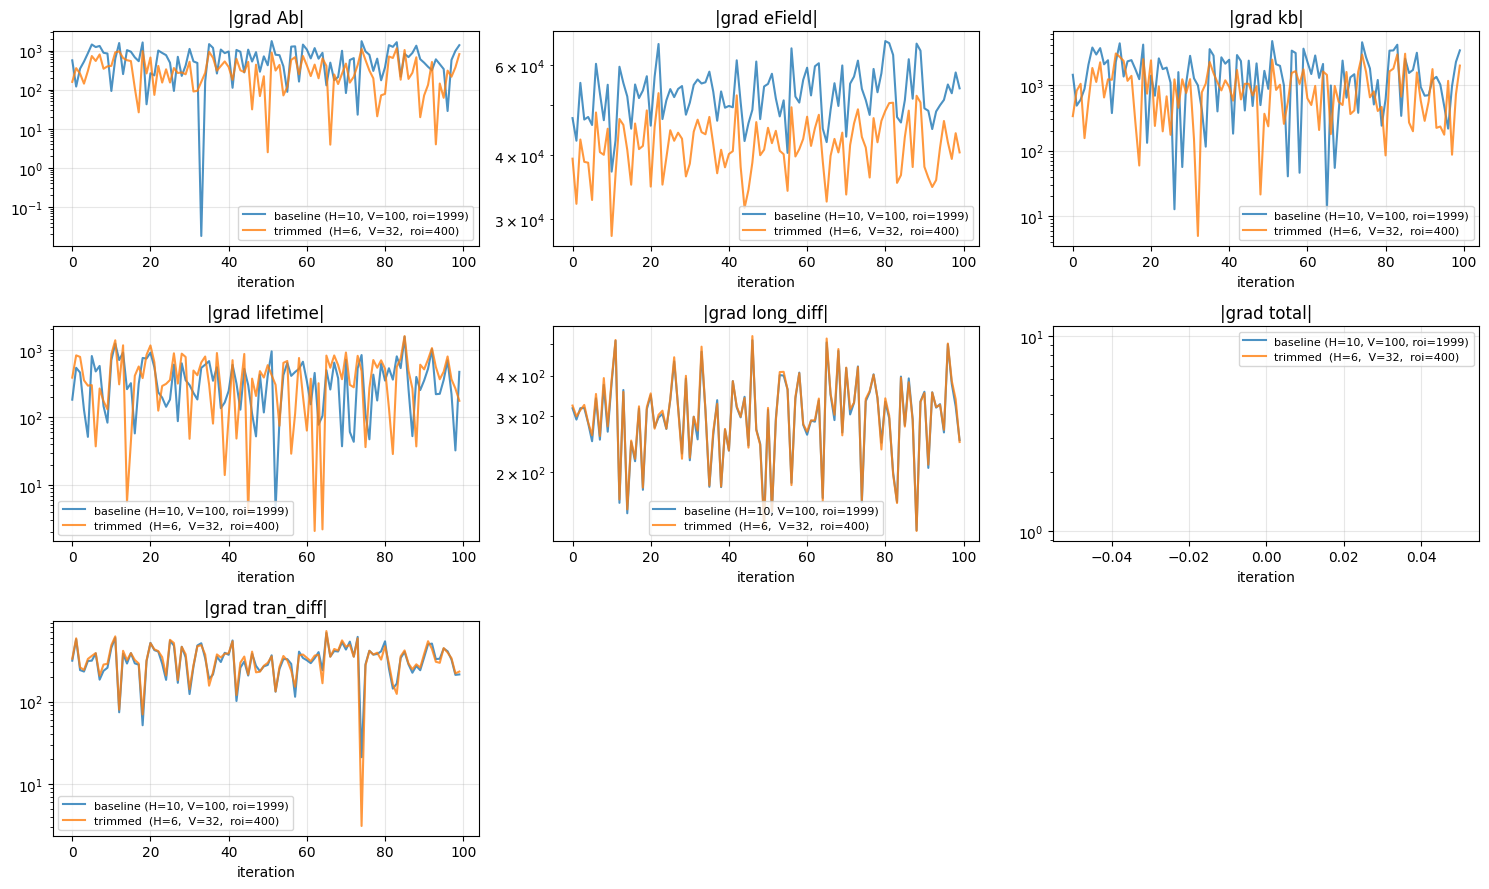

In [26]:
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 3 * rows), squeeze=False)
for ax, p in zip(axes.flat, params):
    for label, h in runs.items():
        g = np.array(h.get(f"{p}_grad", []), dtype=float)
        ax.plot(np.abs(g), label=label, alpha=0.8)
    ax.set_yscale("log")
    ax.set_title(f"|grad {p}|")
    ax.set_xlabel("iteration")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
for ax in axes.flat[n:]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()